# Flight Fare Price Predication

## Problem Statement

## Project Objectives
1) Understand dataset structure and features
2) Perform detailed exploratory data analysis (EDA)
3) Identify patterns, skewness, and potential outliers
4) Analyze the target variable distribution before preprocessing

## Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report,recall_score, f1_score,r2_score, mean_absolute_error, mean_squared_error

In [2]:
# Load Dataset
df= pd.read_csv("Flight_Fare.csv")
# Display first 5 rows
df.head()


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


## Data Preprocessing 

### Dataset Shape & Information


In [4]:
df.shape

(10683, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


## Missing Values & Duplicates Check

In [6]:
df.isnull().sum()


Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [7]:
df.dropna(inplace=True)



In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [9]:
df.duplicated().sum()


np.int64(220)

In [10]:
df.drop_duplicates(inplace=True)


In [11]:
df.duplicated().sum()


np.int64(0)

### Null  value and Duplication value Observation
1) Missing values were removed to avoid introducing bias during model training, as the percentage of missing data was minimal.
2) Duplicate records were removed to prevent model bias caused by repeated observations.



## Statistical Summary (Numerical Features)

In [12]:
df.describe()

,Price
count,10462.000000
mean,9026.790289
std,4624.849541
min,1759.000000
25%,5224.000000
50%,8266.000000
75%,12344.750000
max,79512.000000


### Preprocessing Justification
Feature engineering and preprocessing were performed to transform raw date, time, and categorical information into numerical formats suitable for machine learning models while preserving real-world flight characteristics.

## Exploratory Data Analysis (EDA)

### Target Variable (Price) Distribution

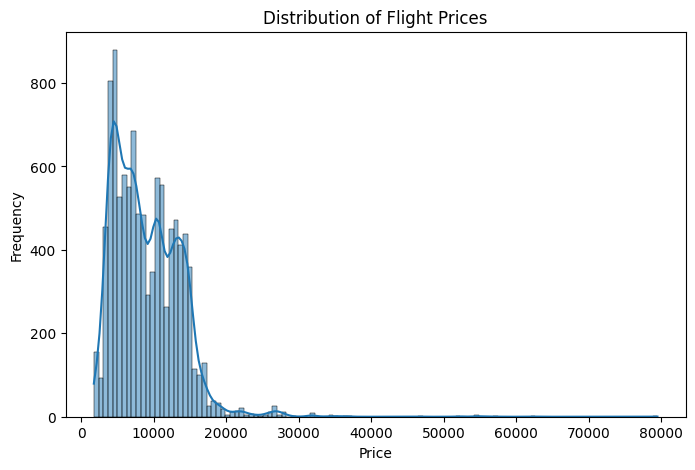

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True)
plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


### Airline vs Price

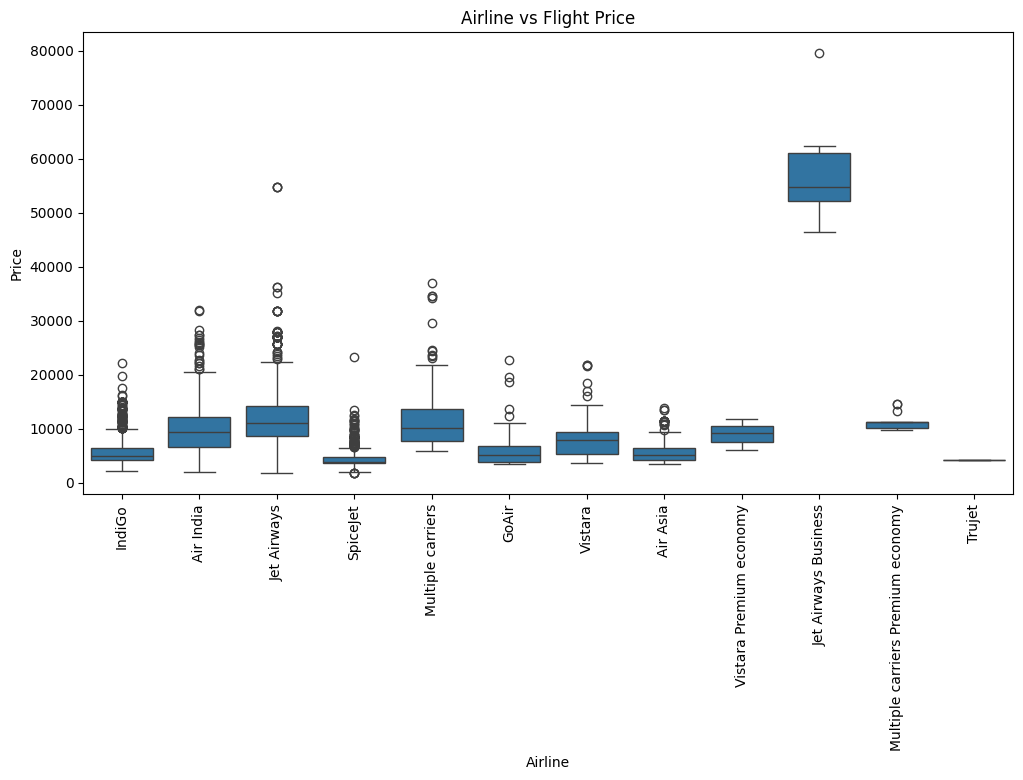

In [14]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Airline", y="Price", data=df)
plt.xticks(rotation=90)
plt.title("Airline vs Flight Price")
plt.show()


## Source vs Price

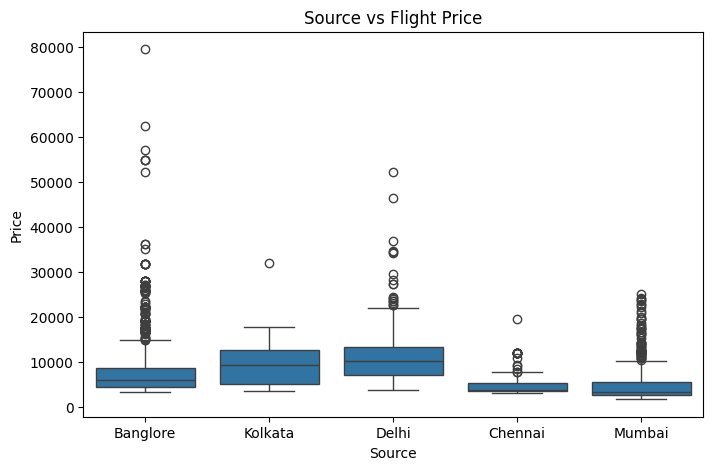

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Source", y="Price", data=df)
plt.title("Source vs Flight Price")
plt.show()


## Destination vs Price


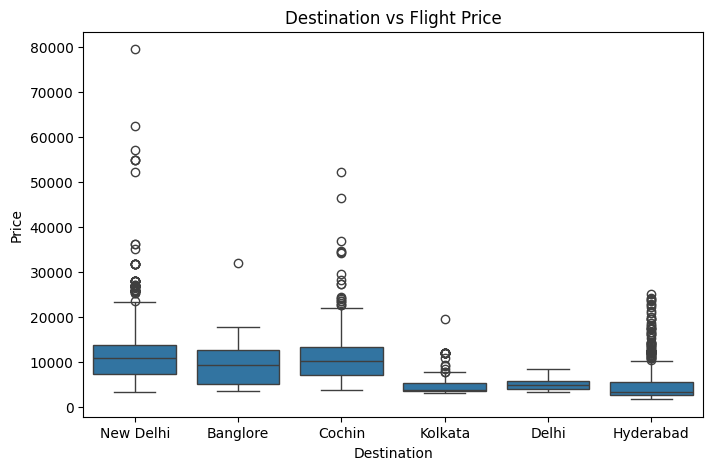

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Destination", y="Price", data=df)
plt.title("Destination vs Flight Price")
plt.show()


## Feature Engineering & Outlier Analysis

### Feature Engineering: Date_of_Journey

In [17]:
df["Date_of_Journey"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y")

df["Journey_Day"] = df["Date_of_Journey"].dt.day
df["Journey_Month"] = df["Date_of_Journey"].dt.month

df.drop("Date_of_Journey", axis=1, inplace=True)


### Feature Engineering: Departure Time

In [18]:
df["Dep_Time"] = pd.to_datetime(df["Dep_Time"])

df["Dep_Hour"] = df["Dep_Time"].dt.hour
df["Dep_Min"] = df["Dep_Time"].dt.minute

df.drop("Dep_Time", axis=1, inplace=True)


### Feature Engineering: Arrival Time

In [19]:
df["Arrival_Time"] = pd.to_datetime(df["Arrival_Time"])

df["Arrival_Hour"] = df["Arrival_Time"].dt.hour
df["Arrival_Min"] = df["Arrival_Time"].dt.minute

df.drop("Arrival_Time", axis=1, inplace=True)


### Feature Engineering: Duration

In [20]:
def convert_duration(duration):
    hours = 0
    minutes = 0
    
    if 'h' in duration:
        hours = int(duration.split('h')[0])
    if 'm' in duration:
        minutes = int(duration.split('m')[-2].split()[-1])
    
    return hours * 60 + minutes

df["Duration"] = df["Duration"].apply(convert_duration)


### Feature Engineering: Total_Stops

In [21]:
df["Total_Stops"] = df["Total_Stops"].replace({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})


### Observations For Overall Feature Engineering 
1) Travel month and day influence ticket pricing
2) Original date column dropped after extraction
3) Early morning and late-night flights often have price variation
4) Hour and minute provide better granularity
5) All durations converted into total minutes
6) Makes duration usable for regression models
7) More stops generally increase travel time and cost
8) Converted into ordinal numerical feature

### Drop Unnecessary Column

In [22]:
df.drop("Route", axis=1, inplace=True)


## Outlier Detection & Treatment

### Identify Numerical Features (Excluding Target)

In [23]:
num_features = ["Duration", "Journey_Day", "Journey_Month", 
                "Dep_Hour", "Dep_Min", "Arrival_Hour", "Arrival_Min"]

num_features


['Duration',
 'Journey_Day',
 'Journey_Month',
 'Dep_Hour',
 'Dep_Min',
 'Arrival_Hour',
 'Arrival_Min']

### Outlier Visualization

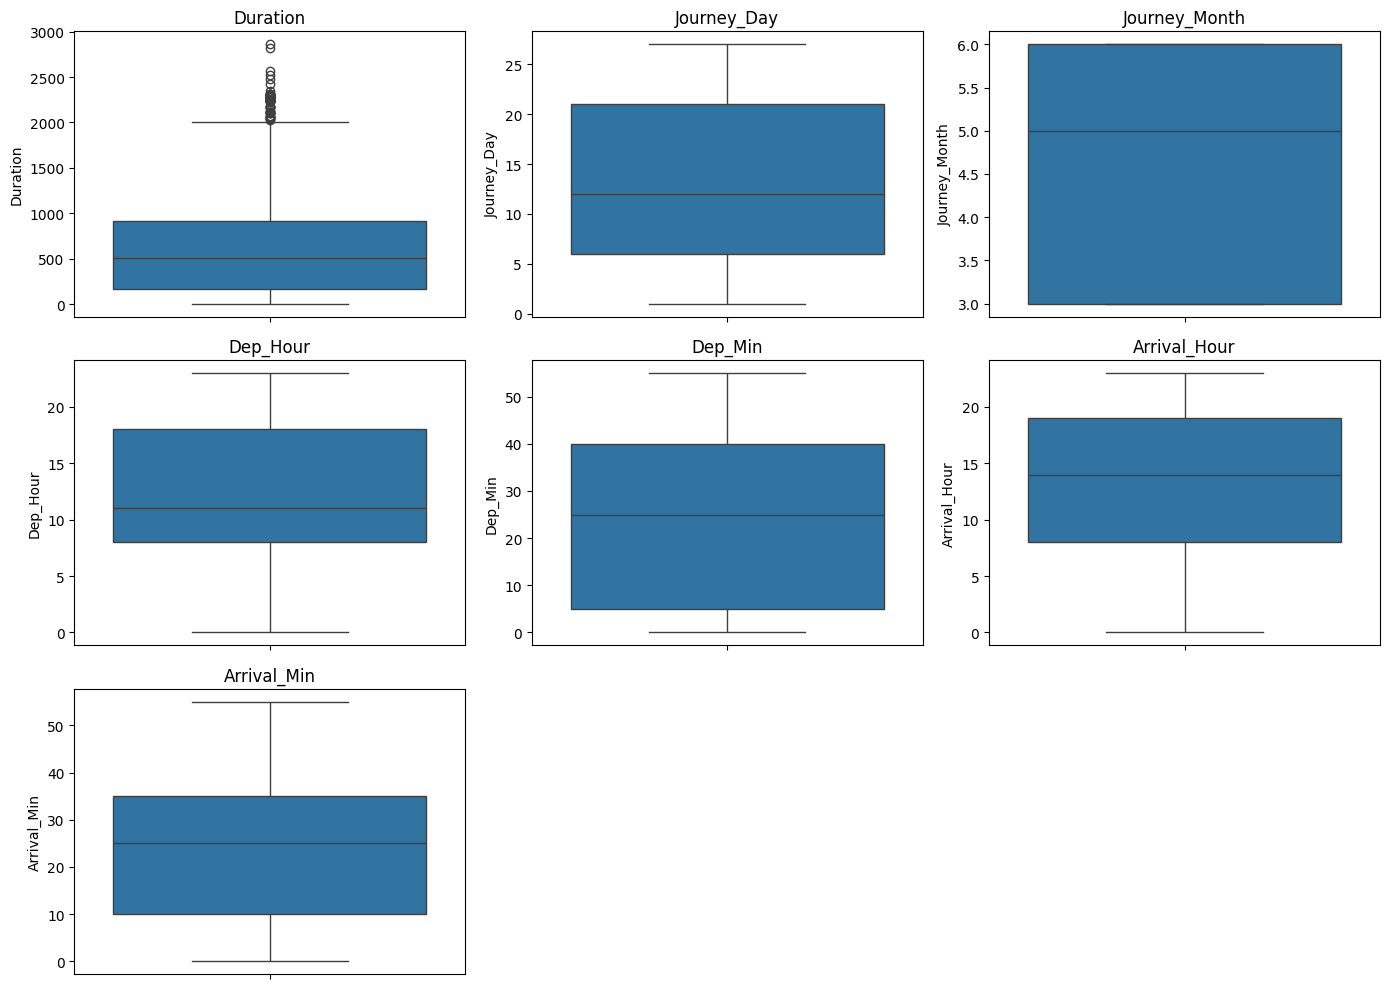

In [24]:
plt.figure(figsize=(14,10))
for i, col in enumerate(num_features):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


### Outlier Treatment Using IQR (Capping)

In [25]:
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


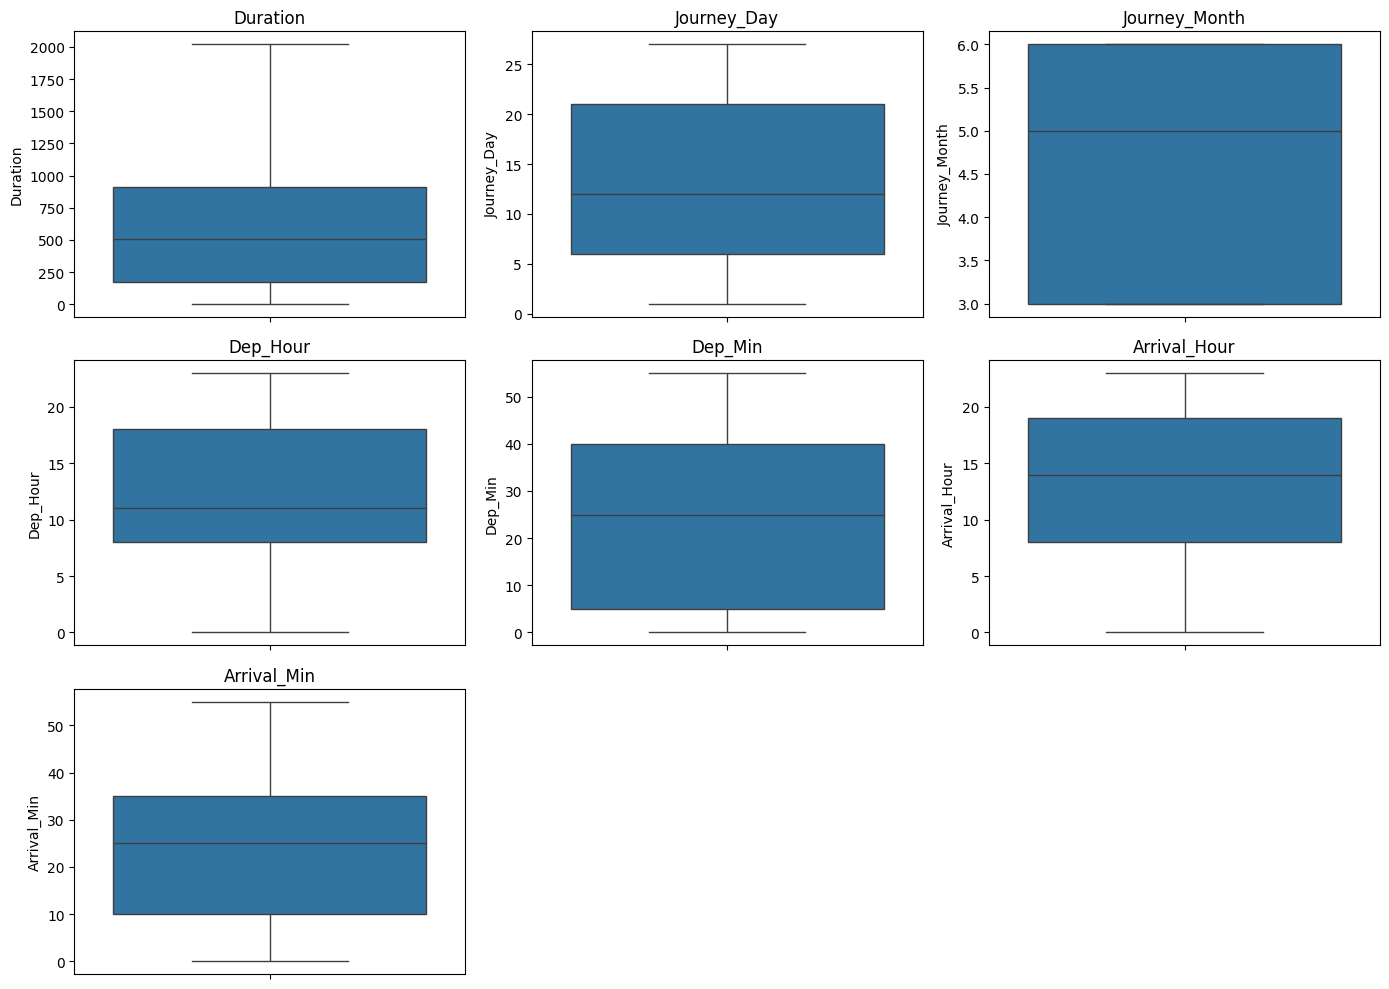

In [26]:
## Recheck boxplot for outliers
plt.figure(figsize=(14,10))
for i, col in enumerate(num_features):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


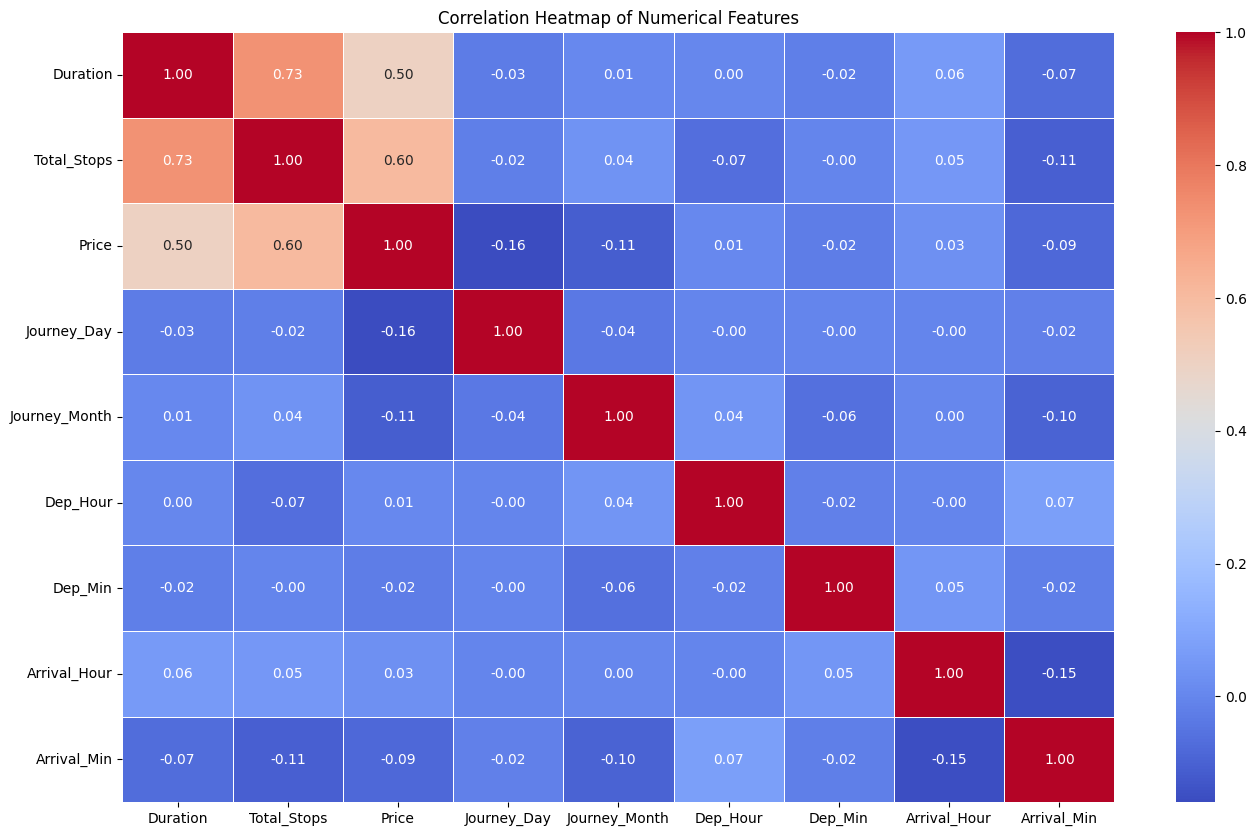

In [27]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(16,10))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


### Heatmap Observation
1) Duration shows a positive correlation with Price, indicating longer flights generally cost more.
2) Total_Stops has a moderate positive correlation with Price.
3) No strong multicollinearity is observed among numerical features, confirming suitability for regression models.

## Identify Categorical Features

In [28]:
cat_features = ["Airline", "Source", "Destination", "Additional_Info"]
cat_features


['Airline', 'Source', 'Destination', 'Additional_Info']

## One-Hot Encoding

In [29]:
df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=True)
df_encoded.head()


,Duration,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Airline_Air India,...,Destination_New Delhi,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,170.0,0,3897,24.0,3.0,22.0,20.0,1.0,10.0,False,...,True,False,False,False,False,False,False,False,True,False
1,445.0,2,7662,1.0,5.0,5.0,50.0,13.0,15.0,True,...,False,False,False,False,False,False,False,False,True,False
2,1140.0,2,13882,9.0,6.0,9.0,25.0,4.0,25.0,False,...,False,False,False,False,False,False,False,False,True,False
3,325.0,1,6218,12.0,5.0,18.0,5.0,23.0,30.0,False,...,False,False,False,False,False,False,False,False,True,False
4,285.0,1,13302,1.0,3.0,16.0,50.0,21.0,35.0,False,...,True,False,False,False,False,False,False,False,True,False


## Separate Features & Target


In [30]:
X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]


### Train–Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
X_train

,Duration,Total_Stops,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Airline_Air India,Airline_GoAir,...,Destination_New Delhi,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
6727,90.0,0,1.0,5.0,9.0,10.0,10.0,40.0,False,False,...,False,False,False,False,False,False,False,False,True,False
6322,540.0,1,9.0,5.0,10.0,0.0,19.0,0.0,False,False,...,False,False,False,False,False,False,False,False,True,False
6874,930.0,1,1.0,6.0,10.0,0.0,1.0,30.0,False,False,...,False,False,False,False,False,False,False,False,True,False
3493,290.0,1,6.0,5.0,8.0,10.0,13.0,0.0,False,False,...,False,False,False,False,False,False,False,False,True,False
611,1215.0,1,21.0,3.0,23.0,0.0,19.0,15.0,True,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5799,170.0,0,3.0,6.0,8.0,30.0,11.0,20.0,False,False,...,False,False,False,False,False,False,False,False,True,False
5247,860.0,1,21.0,3.0,7.0,0.0,21.0,20.0,False,False,...,True,False,False,False,False,True,False,False,False,False
5452,300.0,1,3.0,4.0,10.0,35.0,15.0,35.0,False,False,...,False,False,False,False,False,False,False,False,True,False
861,195.0,0,27.0,4.0,5.0,35.0,8.0,50.0,False,False,...,False,False,False,False,False,False,False,False,True,False


In [33]:
y_train

6727     4575
6322    15554
6874    13377
3493     5069
611      6745
        ...  
5799     4823
5247     7832
5452     5073
861      6015
7367     3543
Name: Price, Length: 8369, dtype: int64

### Baseline Model Evaluation Function

In [34]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    return {
        "Train_R2": r2_score(y_train, y_train_pred),
        "Test_R2": r2_score(y_test, y_test_pred),
        "MAE": mean_absolute_error(y_test, y_test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred))
    }

## Baseline Machine Learning Models

### Linear Regression

In [35]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr_result = evaluate_model(lr, X_train, X_test, y_train, y_test)
lr_result


{'Train_R2': 0.6983670296677754,
 'Test_R2': 0.6617935296823695,
 'MAE': 1771.8348541761268,
 'RMSE': np.float64(2655.5034134640673)}

### Decision Tree Regressor

In [36]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt_result = evaluate_model(dt, X_train, X_test, y_train, y_test)
dt_result


{'Train_R2': 0.9961079295344701,
 'Test_R2': 0.8387558705302166,
 'MAE': 777.1564739608218,
 'RMSE': np.float64(1833.5715594871538)}

### Random Forest Regressor

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf_result = evaluate_model(rf, X_train, X_test, y_train, y_test)
rf_result


{'Train_R2': 0.9823444287457901,
 'Test_R2': 0.8933644714719213,
 'MAE': 671.8252630935318,
 'RMSE': np.float64(1491.1003458904859)}

### K-Nearest Neighbors Regressor

In [38]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()
knn_result = evaluate_model(knn, X_train, X_test, y_train, y_test)
knn_result


{'Train_R2': 0.7146365138953912,
 'Test_R2': 0.5358980347102144,
 'MAE': 1831.3888198757763,
 'RMSE': np.float64(3110.732107369946)}

### Support Vector Regressor (SVR)

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr = SVR()
svr.fit(X_train_scaled, y_train)

y_test_pred = svr.predict(X_test_scaled)

svr_result = {
    "Train_R2": svr.score(X_train_scaled, y_train),
    "Test_R2": r2_score(y_test, y_test_pred),
    "MAE": mean_absolute_error(y_test, y_test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred))
}
svr_result


{'Train_R2': 0.05104266904301191,
 'Test_R2': 0.06168904430463529,
 'MAE': 3380.8195586048255,
 'RMSE': np.float64(4423.125903099219)}

### Baseline Model Comparison Table

In [40]:
baseline_results = pd.DataFrame([
    lr_result,
    dt_result,
    rf_result,
    knn_result,
    svr_result
], index=[
    "Linear Regression",
    "Decision Tree",
    "Random Forest",
    "KNN",
    "SVR"
])

baseline_results


,Train_R2,Test_R2,MAE,RMSE
Linear Regression,0.698367,0.661794,1771.834854,2655.503413
Decision Tree,0.996108,0.838756,777.156474,1833.571559
Random Forest,0.982344,0.893364,671.825263,1491.100346
KNN,0.714637,0.535898,1831.388820,3110.732107
SVR,0.051043,0.061689,3380.819559,4423.125903


## Advance Machine learning with hyperparameter tuning

### Overfit Check 

In [41]:
dt_result 

{'Train_R2': 0.9961079295344701,
 'Test_R2': 0.8387558705302166,
 'MAE': 777.1564739608218,
 'RMSE': np.float64(1833.5715594871538)}

In [42]:
### Hyperparameter Tuning – Decision Tree
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

dt_param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

dt_tuned_result = evaluate_model(
    best_dt, X_train, X_test, y_train, y_test
)

dt_tuned_result


{'Train_R2': 0.9502826240194228,
 'Test_R2': 0.8622882539911387,
 'MAE': 770.0173327190407,
 'RMSE': np.float64(1694.4993256915204)}

In [43]:
## Overfit comparsion 
overfitting_check = pd.DataFrame({
    "Model": ["Decision Tree (Baseline)", "Decision Tree (Tuned)"],
    "Train_R2": [dt_result["Train_R2"], dt_tuned_result["Train_R2"]],
    "Test_R2": [dt_result["Test_R2"], dt_tuned_result["Test_R2"]]
})

overfitting_check


,Model,Train_R2,Test_R2
0,Decision Tree (Baseline),0.996108,0.838756
1,Decision Tree (Tuned),0.950283,0.862288


In [44]:
### Hyperparameter Tuning – Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

rf_tuned_result = evaluate_model(
    best_rf, X_train, X_test, y_train, y_test
)

rf_tuned_result


{'Train_R2': 0.9823316426374282,
 'Test_R2': 0.8943354044448198,
 'MAE': 669.1457227549882,
 'RMSE': np.float64(1484.2964733116387)}

In [45]:
### Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error"
)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_

gb_result = evaluate_model(
    best_gb, X_train, X_test, y_train, y_test
)

gb_result


{'Train_R2': 0.9398329217928918,
 'Test_R2': 0.879575195611888,
 'MAE': 884.8091431463652,
 'RMSE': np.float64(1584.578951724285)}

In [46]:
### Hyperparameter Tuning – Support Vector Regressor (SVR)
from sklearn.svm import SVR

svr_param_grid = {
    "C": [1, 10, 100],
    "gamma": ["scale", 0.1, 0.01],
    "kernel": ["rbf"]
}

svr_grid = GridSearchCV(
    SVR(),
    param_grid=svr_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error"
)

svr_grid.fit(X_train_scaled, y_train)

best_svr = svr_grid.best_estimator_

y_test_pred = best_svr.predict(X_test_scaled)

svr_tuned_result = {
    "Train_R2": best_svr.score(X_train_scaled, y_train),
    "Test_R2": r2_score(y_test, y_test_pred),
    "MAE": mean_absolute_error(y_test, y_test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred))
}

svr_tuned_result


{'Train_R2': 0.5860941852393958,
 'Test_R2': 0.6332216727269631,
 'MAE': 1583.6118242012433,
 'RMSE': np.float64(2765.398613775162)}

In [47]:
### Advanced Model Performance Summary
advanced_results = pd.DataFrame([
    dt_tuned_result,
    rf_tuned_result,
    gb_result,
    svr_tuned_result
], index=[
    "Decision Tree (Tuned)",
    "Random Forest (Tuned)",
    "Gradient Boosting",
    "SVR (Tuned)"
])

advanced_results


,Train_R2,Test_R2,MAE,RMSE
Decision Tree (Tuned),0.950283,0.862288,770.017333,1694.499326
Random Forest (Tuned),0.982332,0.894335,669.145723,1484.296473
Gradient Boosting,0.939833,0.879575,884.809143,1584.578952
SVR (Tuned),0.586094,0.633222,1583.611824,2765.398614


## Final Model Comparison (All Models)

In [48]:
final_results = pd.DataFrame([
    lr_result,
    dt_result,
    rf_result,
    knn_result,
    svr_result,
    dt_tuned_result,
    rf_tuned_result,
    gb_result,
    svr_tuned_result
], index=[
    "Linear Regression",
    "Decision Tree (Baseline)",
    "Random Forest (Baseline)",
    "KNN",
    "SVR (Baseline)",
    "Decision Tree (Tuned)",
    "Random Forest (Tuned)",
    "Gradient Boosting",
    "SVR (Tuned)"
])

final_results


,Train_R2,Test_R2,MAE,RMSE
Linear Regression,0.698367,0.661794,1771.834854,2655.503413
Decision Tree (Baseline),0.996108,0.838756,777.156474,1833.571559
Random Forest (Baseline),0.982344,0.893364,671.825263,1491.100346
KNN,0.714637,0.535898,1831.388820,3110.732107
SVR (Baseline),0.051043,0.061689,3380.819559,4423.125903
Decision Tree (Tuned),0.950283,0.862288,770.017333,1694.499326
Random Forest (Tuned),0.982332,0.894335,669.145723,1484.296473
Gradient Boosting,0.939833,0.879575,884.809143,1584.578952
SVR (Tuned),0.586094,0.633222,1583.611824,2765.398614


## Final Model Selection

## Feature Importance Analysis

In [49]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)


,Feature,Importance
0,Duration,0.440635
2,Journey_Day,0.094945
32,Additional_Info_In-flight meal not included,0.076315
12,Airline_Jet Airways Business,0.069842
11,Airline_Jet Airways,0.059710
3,Journey_Month,0.049514
27,Destination_New Delhi,0.028362
1,Total_Stops,0.026900
6,Arrival_Hour,0.025553
4,Dep_Hour,0.021794


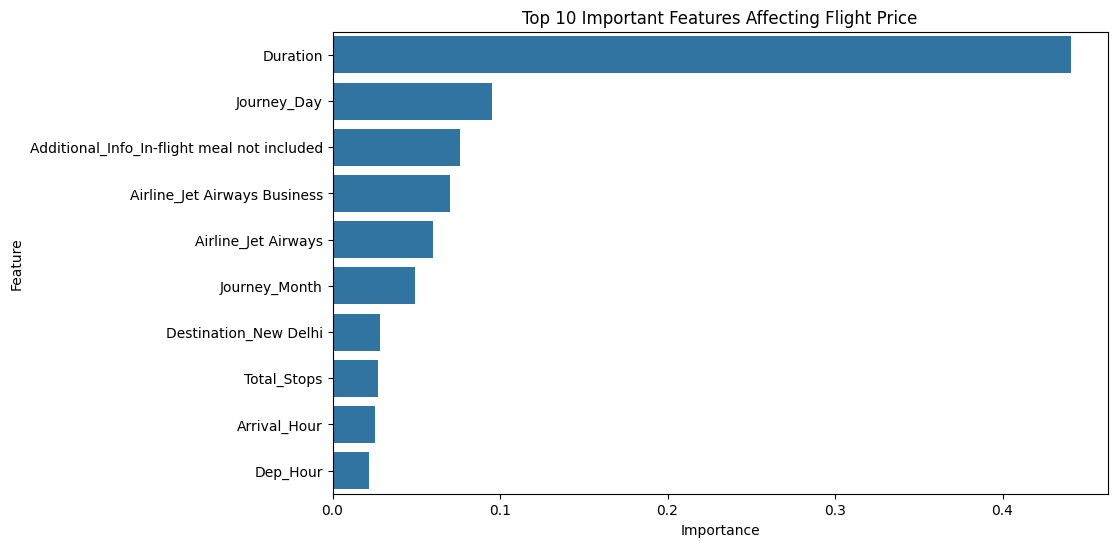

In [50]:
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)
plt.title("Top 10 Important Features Affecting Flight Price")
plt.show()


## Feature Importance Interpretation
1) Duration is the most important factor influencing flight price
2) Total_Stops significantly impacts fare
3) Airline and route-related features strongly affect pricing
4) Confirms real-world airline pricing logic

## Challenges Faced During the Project
1) Date_of_Journey, Arrival_Time, Dep_Time were not directly usable
2) Extreme values could distort model learning
3) Decision Tree showed large train–test performance gap
4) Airline and route features increased dimensionality

## How Challenges Were Handled
1) Extracted day, month, hour, and minute from date/time features
2) Used IQR-based capping instead of removing outliers
3) Applied hyperparameter tuning to control overfitting
4) Used One-Hot Encoding with drop_first=True to manage dimensionality

## Final Conclusion